In [1]:
import copy

import jax
import jax.numpy as jnp
import numpy as np
import seaborn as sns
from scipy.io import loadmat

from nanopinv.physics import travel_time_points

jax.config.update("jax_enable_x64", True)

from pathlib import Path

import gstools as gs
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import skfmm
from gstools import covmodel
from tqdm.auto import tqdm, trange

from nanopinv.physics import travel_time_points
from nanopinv.prior import CholeskyPrior

# # ignore plot warnings in gstools
# import warnings
# warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
M = loadmat("AM13_data.mat")
N_data, N_dim = M["S"].shape
sources = M["S"]  # Shape: (N_data, N_dim)
receivers = M["R"]  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\field\generator.py:237: UserWarning: gstools.RandMeth: **kwargs are ignored
  warnings.warn("gstools.RandMeth: **kwargs are ignored")


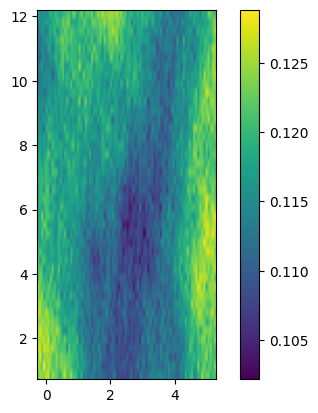

In [3]:
# Set up prior
dx = 0.135

x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)
m0 = 0.12
C_m = covmodel.Spherical(dim=2, var=0.00003, len_scale=7)  # '0.00003 Sph(7)'

# Model parameters: Velocity field


srf = gs.SRF(C_m, mean=m0, generator_kwargs={"mode_no": 50})
samples = srf.structured((x, y))
# samples = srf((r[:, 0], r[:, 1]))

plt.imshow(samples, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis)
plt.colorbar()

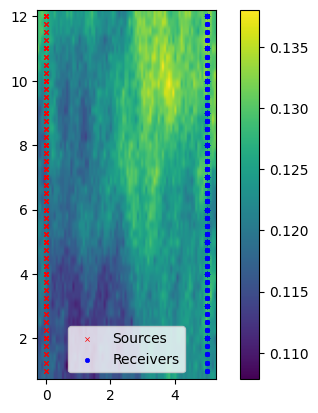

In [4]:
# Forward model
# def travel_time(m):

plt.figure()

realisation = srf.structured((x, y), seed=0)
plt.imshow(
    realisation, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

plt.scatter(
    sources[:, 0], sources[:, 1], c="red", marker="x", s=10, lw=0.5, label="Sources"
)
plt.scatter(
    receivers[:, 0],
    receivers[:, 1],
    c="blue",
    marker="o",
    s=10,
    lw=0.5,
    label="Receivers",
)

plt.legend()

In [5]:
receivers
travel_times = travel_time_points(
    [x, y], speeds=realisation, source=sources[55], receivers=receivers, window=1
)


def forward_model(m):
    # Sources and receivers are not unique, but rather set up as a grid
    # For simplicity, we iterate over all sources and compute the receivers for each source, then concatenate appropriate
    travel_times = np.empty(shape=(N_data,))

    unique_sources, inverse_indices = np.unique(sources, axis=0, return_inverse=True)
    for i, u_src in enumerate(unique_sources):
        mask = inverse_indices == i
        associated_receivers = receivers[mask]
        travel_times[mask] = travel_time_points(
            [x, y], speeds=m, source=u_src, receivers=associated_receivers, window=1
        )

    return travel_times

    # # u_sources, u_indices, u_inverse, u_counts = np.unique(sources, axis=0, return_inverse=True, return_index=True)
    # # for u_source, u_index, u_count in zip(u_sources, u_indices, u_counts):
    #     # # source = u_source
    #     # # Indices of this source

    #     # # receivers = receivers[]
    #     # # Get the indices of the data points corresponding to this unique source
    #     # indices = np.where(u_inverse == u_index)[0]
    #     # # Get the corresponding receivers for this source
    #     # u_receivers = receivers[indices]
    #     # # Compute travel times for this source and its corresponding receivers
    #     # travel_times[indices] = travel_time_points([x, y], speeds=m, source=u_source, receivers=u_receivers, window=1)

    # travel_times = travel_time_points([x, y], speeds = m, source=sources[55], receivers=receivers, window=1)


# plt.imshow(travel_times)
# plt.colorbar()

# print

# forward_model(realisation).shape

In [6]:
# # 1. Get predictions from both implementations
# print("Running Numpy Baseline...")
# out_np = np_fwd_call()

# print("Running JAX Multiprocess...")
# out_jax_mp = jax_fwd_mp_call().squeeze()
# out_jax_mp.block_until_ready() # Ensure JAX finishes computing

# # Convert JAX array back to standard Numpy for direct comparison
# out_jax_mp_np = np.asarray(out_jax_mp)

# # 2. Compare Shapes
# print(f"\n--- Shape Validation ---")
# print(f"Numpy output shape:   {out_np.shape}")
# print(f"JAX MP output shape:  {out_jax_mp_np.shape}")
# assert out_np.shape == out_jax_mp_np.shape, "Shapes do not match!"
# print("Shapes match perfectly.")

# # 3. Compare Values
# print(f"\n--- Value Validation ---")
# abs_diff = np.abs(out_np - out_jax_mp_np)
# max_diff = np.max(abs_diff)
# mean_diff = np.mean(abs_diff)

# print(f"Max absolute difference:  {max_diff:.8e}")
# print(f"Mean absolute difference: {mean_diff:.8e}")

# # Check with standard 1e-5 tolerance for float32
# is_close = np.allclose(out_np, out_jax_mp_np, atol=1e-5, rtol=1e-5)

# if is_close:
#     print("\n✅ VALIDATION SUCCESSFUL: The Numpy and JAX multiprocessing outputs match!")
# else:
#     print("\n❌ VALIDATION FAILED: The outputs differ beyond acceptable tolerance levels of acceptable float32 tolerance.")

#     # Show the worst offending mismatch
#     worst_idx = np.argmax(abs_diff)
#     print(f"Worst mismatch at index {worst_idx}: Numpy={out_np[worst_idx]}, JAX={out_jax_mp_np[worst_idx]}")

In [14]:
%load_ext autoreload
%autoreload 2

import statistics as stats
import time

import jax
import jax.numpy as jnp
import numpy as np
import polars as pl

from nanopinv.physics_jax import build_time_travel_points

# 1. Ensure 64-bit precision across the board
m_np = np.asarray(realisation, dtype=np.float64)
m_jax = jnp.asarray(realisation, dtype=jnp.float64)

x_j = jnp.asarray(x, dtype=jnp.float64)
y_j = jnp.asarray(y, dtype=jnp.float64)
sources_j = jnp.asarray(sources, dtype=jnp.float64)
receivers_j = jnp.asarray(receivers, dtype=jnp.float64)

# 2. Build the new JAX model
print("Building the JAX Multiprocess Model...")
forward_model_jax_mp = build_time_travel_points(sources_j, receivers_j, x_j, y_j)


def np_fwd_call():
    return forward_model(m_np)


def jax_fwd_mp_call():
    return forward_model_jax_mp(m_jax)


# 3. Test and Validate Outputs (ensuring shapes and strict float64 values are perfectly equivalent)
print("\n--- Output Validations ---")
out_np = np_fwd_call()
out_jax = jax_fwd_mp_call().squeeze()
out_jax.block_until_ready()

out_jax_np = np.asarray(out_jax)

print(f"Numpy Baseline Shape:  {out_np.shape} | Dtype: {out_np.dtype}")
print(f"JAX Model Shape:       {out_jax_np.shape} | Dtype: {out_jax_np.dtype}")
assert out_np.shape == out_jax_np.shape, "Shapes do not match!"

abs_diff = np.abs(out_np - out_jax_np)
max_diff = np.max(abs_diff)
mean_diff = np.mean(abs_diff)

print(f"Max absolute difference:  {max_diff:.8e}")
print(f"Mean absolute difference: {mean_diff:.8e}")

# Strict test for float64 precision
if np.allclose(out_np, out_jax_np, atol=1e-12, rtol=1e-12):
    print(
        "✅ VALIDATION SUCCESSFUL: The Numpy and JAX outputs strictly match down to precision."
    )
else:
    print("❌ VALIDATION FAILED: The outputs differ beyond 1e-12 tolerances.")
    idx = np.argmax(abs_diff)
    print(f"Worst mismatch at index {idx}: Numpy={out_np[idx]}, JAX={out_jax_np[idx]}")


# 4. Standard Benchmark Execution
def bench_fn(fn, is_jax=False, n_warmup=3, n_runs=20):
    for _ in range(n_warmup):
        res = fn()
        if is_jax:
            res.block_until_ready()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        res = fn()
        if is_jax:
            res.block_until_ready()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return times


print(f"\n--- Benchmarking Models (Runs=20) ---")
np_times = bench_fn(np_fwd_call, is_jax=False)
jax_times = bench_fn(jax_fwd_mp_call, is_jax=True)

df_bench = pl.DataFrame(
    {
        "Implementation": ["Numpy (Sequential)", "JAX (Multiprocessing)"],
        "Mean (ms)": [1e3 * stats.mean(t) for t in [np_times, jax_times]],
        "Median (ms)": [1e3 * stats.median(t) for t in [np_times, jax_times]],
        "Min (ms)": [1e3 * min(t) for t in [np_times, jax_times]],
        "Max (ms)": [1e3 * max(t) for t in [np_times, jax_times]],
    }
)
print(df_bench)

np_mean = stats.mean(np_times)
jax_mean = stats.mean(jax_times)
print(f"\n🚀 Final Speedup vs Baseline: {np_mean / jax_mean:.3f}x")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Building the JAX Multiprocess Model...

--- Output Validations ---
Vmap Output Dtype: float64
Numpy Baseline Shape:  (702,) | Dtype: float64
JAX Model Shape:       (702,) | Dtype: float64
Max absolute difference:  2.41574667e-06
Mean absolute difference: 1.82476440e-06
❌ VALIDATION FAILED: The outputs differ beyond 1e-12 tolerances.
Worst mismatch at index 206: Numpy=58.46087785296989, JAX=58.46088026871656

--- Benchmarking Models (Runs=20) ---
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vmap Output Dtype: float64
Vma